In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sample = [
    2, 1, 4, 0, 0, 5, 1, 1, 0, 2, 4, 5, 1, 2, 2, 4, 2, 5, 2, 1, 3, 1, 1, 1, 0,
    0, 2, 0, 3, 5, 3, 3, 2, 2, 1, 3, 0, 2, 2, 0, 1, 0, 1, 3, 4, 3, 5, 3, 0, 1,
    0, 2, 3, 0, 2, 4, 0, 3, 2, 1, 2, 3, 1, 1, 1, 1, 6, 1, 4, 2, 3, 2, 3, 4, 3,
    2, 2, 4, 7, 3, 2, 0, 5, 3, 3, 1, 3, 1, 4, 2, 5, 2, 1, 4, 1, 5, 4, 2, 1, 1
]

len(sample)

100

In [3]:
variation_series = sorted(sample)

df_variation = pd.DataFrame({
    "Варіаційний ряд": variation_series
})

df_variation

,Варіаційний ряд
0,0
1,0
2,0
3,0
4,0
...,...
95,5
96,5
97,5
98,6


In [4]:
df_info = pd.DataFrame({
    "Об'єм вибірки": [len(sample)],
    "Мінімальний елемент": [min(sample)],
    "Максимальний елемент": [max(sample)],
    "Розмах вибірки": [max(sample) - min(sample)]
})

df_info    

,Об'єм вибірки,Мінімальний елемент,Максимальний елемент,Розмах вибірки
0,100,0,7,7


In [5]:
values = sorted(pd.Series(sample).unique())
frequencies = pd.Series(sample).value_counts(sort=False).sort_index()
relative_frequencies = frequencies / len(sample)

df_stat_dist = pd.DataFrame({
    "Значення": values,
    "Частоти": frequencies.values,
    "Кумулятивні частоти": frequencies.cumsum().values,
    "Відносні частоти": relative_frequencies.values,
    "Кумулятивні відносні частоти": relative_frequencies.cumsum().values
})

df_stat_dist

,Значення,Частоти,Кумулятивні частоти,Відносні частоти,Кумулятивні відносні частоти
0,0,14,14,0.14,0.14
1,1,24,38,0.24,0.38
2,2,23,61,0.23,0.61
3,3,18,79,0.18,0.79
4,4,11,90,0.11,0.90
5,5,8,98,0.08,0.98
6,6,1,99,0.01,0.99
7,7,1,100,0.01,1.00


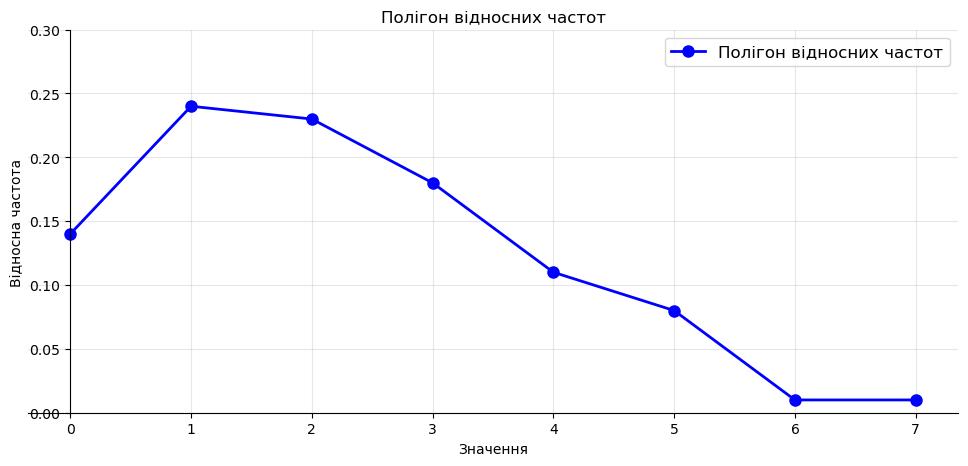

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")

ax.plot(
    df_stat_dist["Значення"],
    df_stat_dist["Відносні частоти"],
    "o-",
    linewidth=2,
    markersize=8,
    color="blue",
    label="Полігон відносних частот"
)

ax.set_xticks(df_stat_dist["Значення"])
ax.set_yticks(np.arange(0, 0.31, 0.05))

ax.set_xlabel("Значення")
ax.set_ylabel("Відносна частота")
ax.set_title("Полігон відносних частот")
ax.legend(fontsize=12)

plt.grid(alpha=0.3)
plt.show()

In [9]:
def plot_empirical_cdf(x_sample, y_sample):
    plt.plot(
        [x_sample[0] - 0.5, x_sample[0]],
        [0, 0],
        linewidth=2,
        color="blue"
    )

    for i in range(len(x_sample) - 1):
        plt.plot(
            [x_sample[i], x_sample[i + 1]],
            [y_sample[i], y_sample[i]],
            linewidth=2,
            color="blue"
        )
        plt.scatter(x_sample[i], y_sample[i], marker="<", color="blue")

    plt.plot(
        [x_sample[-1], x_sample[-1] + 0.5],
        [1, 1],
        linewidth=2,
        color="blue"
    )

    plt.scatter(x_sample[-1], 1, marker="<", color="blue")

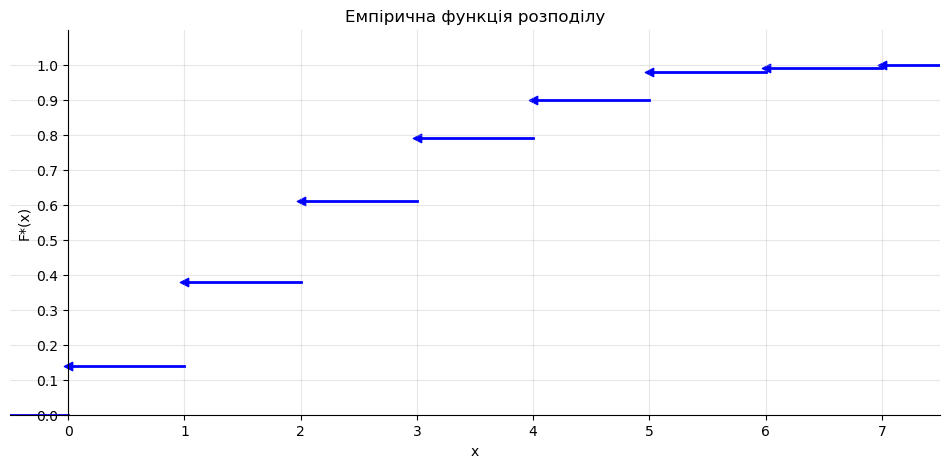

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")

ax.set_xlim(
    df_stat_dist["Значення"].min() - 0.5,
    df_stat_dist["Значення"].max() + 0.5
)

ax.set_ylim(0, 1.1)
ax.set_xticks(df_stat_dist["Значення"])
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.set_xlabel("x")
ax.set_ylabel("F*(x)")
ax.set_title("Емпірична функція розподілу")

plot_empirical_cdf(
    df_stat_dist["Значення"].tolist(),
    df_stat_dist["Кумулятивні відносні частоти"].tolist()
)

plt.grid(alpha=0.3)
plt.show()

In [11]:
df_empirical_function = pd.DataFrame({
    "Інтервал": [
        "x <= 0",
        "0 < x <= 1",
        "1 < x <= 2",
        "2 < x <= 3",
        "3 < x <= 4",
        "4 < x <= 5",
        "5 < x <= 6",
        "6 < x <= 7",
        "x > 7"
    ],
    "F*(x)": [
        0,
        0.14,
        0.38,
        0.61,
        0.79,
        0.90,
        0.98,
        0.99,
        1
    ]
})

df_empirical_function

,Інтервал,F*(x)
0,x <= 0,0.00
1,0 < x <= 1,0.14
2,1 < x <= 2,0.38
3,2 < x <= 3,0.61
4,3 < x <= 4,0.79
5,4 < x <= 5,0.90
6,5 < x <= 6,0.98
7,6 < x <= 7,0.99
8,x > 7,1.00


In [12]:
n = len(sample)

sample_mean = np.mean(sample)

sample_mean

np.float64(2.21)

In [13]:
sample_variance = np.var(sample)

sample_variance

np.float64(2.5058999999999996)

In [14]:
corrected_sample_variance = np.var(sample, ddof=1)

corrected_sample_variance

np.float64(2.531212121212121)

In [15]:
sample_median = np.median(sample)

sample_median

np.float64(2.0)

In [16]:
sample_std = np.sqrt(sample_variance)

sample_std

np.float64(1.5830034744118535)

In [17]:
sample_asymmetry = np.mean((np.array(sample) - sample_mean) ** 3) / sample_std ** 3

sample_asymmetry

np.float64(0.5450225918494218)

In [18]:
sample_excess = np.mean((np.array(sample) - sample_mean) ** 4) / sample_std ** 4 - 3

sample_excess

np.float64(-0.2563420553759137)

In [20]:
df_characteristics = pd.DataFrame({
    "Характеристика": [
        "Об'єм вибірки",
        "Вибіркове середнє",
        "Вибіркова дисперсія",
        "Виправлена вибіркова дисперсія",
        "Вибіркова медіана",
        "Вибіркова мода",
        "Вибірковий коефіцієнт асиметрії",
        "Вибірковий коефіцієнт ексцесу"
    ],
    "Значення": [
        n,
        sample_mean,
        sample_variance,
        corrected_sample_variance,
        sample_median,
        pd.Series(sample).mode().iloc[0],
        sample_asymmetry,
        sample_excess
    ]
})

df_characteristics

,Характеристика,Значення
0,Об'єм вибірки,100.000000
1,Вибіркове середнє,2.210000
2,Вибіркова дисперсія,2.505900
3,Виправлена вибіркова дисперсія,2.531212
4,Вибіркова медіана,2.000000
5,Вибіркова мода,1.000000
6,Вибірковий коефіцієнт асиметрії,0.545023
7,Вибірковий коефіцієнт ексцесу,-0.256342


In [23]:
p_geomІ = 1 / (1 + sample_mean)
lambda_poisson = sample_mean

p_geom, lambda_poisson

(np.float64(0.3115264797507788), np.float64(2.21))

In [24]:
x_values = df_stat_dist["Значення"]

geom_probabilities = p_geom * (1 - p_geom) ** x_values

df_geom = pd.DataFrame({
    "Значення": x_values,
    "Відносні частоти вибірки": df_stat_dist["Відносні частоти"],
    "Ймовірності Geom": geom_probabilities
})

df_geom

,Значення,Відносні частоти вибірки,Ймовірності Geom
0,0,0.14,0.311526
1,1,0.24,0.214478
2,2,0.23,0.147662
3,3,0.18,0.101662
4,4,0.11,0.069991
5,5,0.08,0.048187
6,6,0.01,0.033176
7,7,0.01,0.022841


In [26]:
import math

poisson_probabilities = [
    math.exp(-lambda_poisson) * lambda_poisson ** k / math.factorial(k)
    for k in x_values
]

df_poisson = pd.DataFrame({
    "Значення": x_values,
    "Відносні частоти вибірки": df_stat_dist["Відносні частоти"],
    "Ймовірності Poiss": poisson_probabilities
})

df_poisson

,Значення,Відносні частоти вибірки,Ймовірності Poiss
0,0,0.14,0.109701
1,1,0.24,0.242438
2,2,0.23,0.267894
3,3,0.18,0.197349
4,4,0.11,0.109035
5,5,0.08,0.048194
6,6,0.01,0.017751
7,7,0.01,0.005604


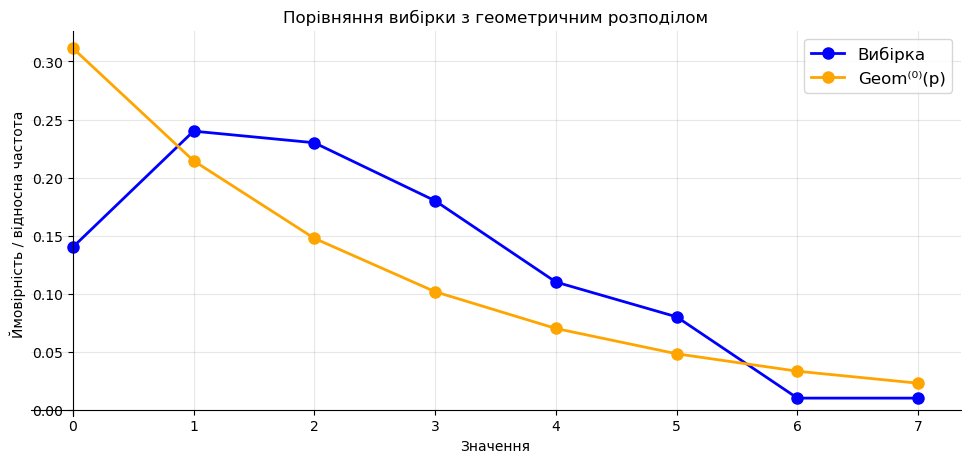

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")

ax.plot(
    x_values,
    df_stat_dist["Відносні частоти"],
    "o-",
    linewidth=2,
    markersize=8,
    color="blue",
    label="Вибірка"
)

ax.plot(
    x_values,
    geom_probabilities,
    "o-",
    linewidth=2,
    markersize=8,
    color="orange",
    label="Geom⁽⁰⁾(p)"
)

ax.set_xticks(x_values)
ax.set_title("Порівняння вибірки з геометричним розподілом")
ax.set_xlabel("Значення")
ax.set_ylabel("Ймовірність / відносна частота")
ax.legend(fontsize=12)

plt.grid(alpha=0.3)
plt.show()

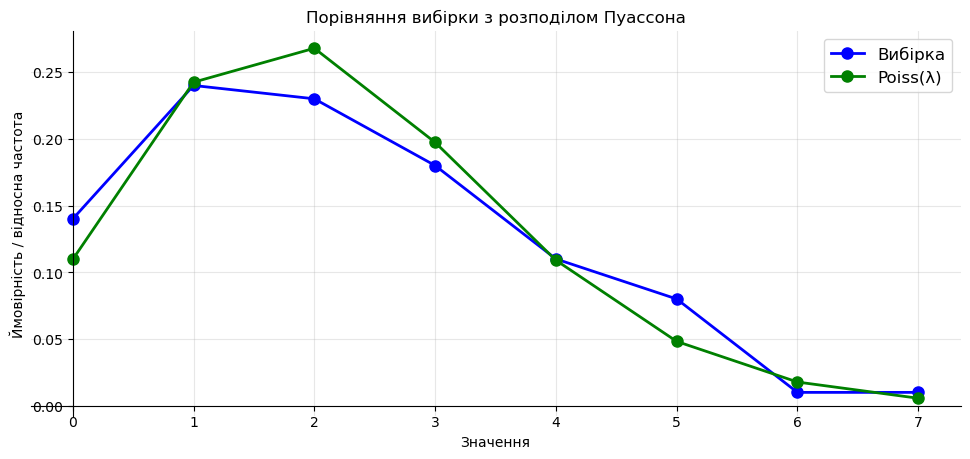

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")

ax.plot(
    x_values,
    df_stat_dist["Відносні частоти"],
    "o-",
    linewidth=2,
    markersize=8,
    color="blue",
    label="Вибірка"
)

ax.plot(
    x_values,
    poisson_probabilities,
    "o-",
    linewidth=2,
    markersize=8,
    color="green",
    label="Poiss(λ)"
)

ax.set_xticks(x_values)
ax.set_title("Порівняння вибірки з розподілом Пуассона")
ax.set_xlabel("Значення")
ax.set_ylabel("Ймовірність / відносна частота")
ax.legend(fontsize=12)

plt.grid(alpha=0.3)
plt.show()

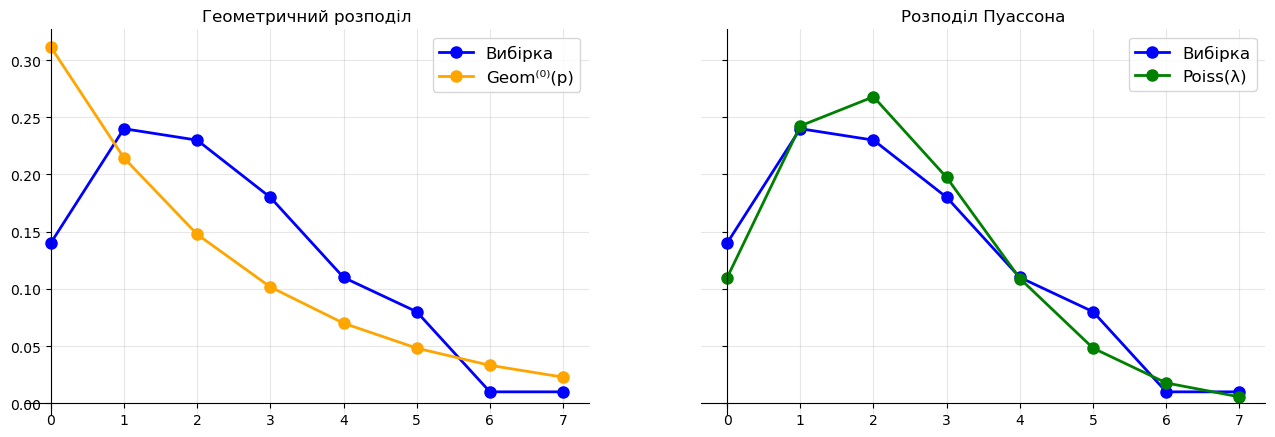

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), sharey=True)

for i in range(2):
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["left"].set_position("zero")
    ax[i].spines["bottom"].set_position("zero")
    ax[i].set_xticks(x_values)
    ax[i].grid(alpha=0.3)

ax[0].plot(
    x_values,
    df_stat_dist["Відносні частоти"],
    "o-",
    linewidth=2,
    markersize=8,
    color="blue",
    label="Вибірка"
)

ax[0].plot(
    x_values,
    geom_probabilities,
    "o-",
    linewidth=2,
    markersize=8,
    color="orange",
    label="Geom⁽⁰⁾(p)"
)

ax[0].set_title("Геометричний розподіл")
ax[0].legend(fontsize=12)

ax[1].plot(
    x_values,
    df_stat_dist["Відносні частоти"],
    "o-",
    linewidth=2,
    markersize=8,
    color="blue",
    label="Вибірка"
)

ax[1].plot(
    x_values,
    poisson_probabilities,
    "o-",
    linewidth=2,
    markersize=8,
    color="green",
    label="Poiss(λ)"
)

ax[1].set_title("Розподіл Пуассона")
ax[1].legend(fontsize=12)

plt.show()

In [30]:
df_distribution_comparison = pd.DataFrame({
    "Значення": x_values,
    "Відносні частоти вибірки": df_stat_dist["Відносні частоти"],
    "Geom⁽⁰⁾(p)": geom_probabilities,
    "Poiss(λ)": poisson_probabilities
})

df_distribution_comparison

,Значення,Відносні частоти вибірки,Geom⁽⁰⁾(p),Poiss(λ)
0,0,0.14,0.311526,0.109701
1,1,0.24,0.214478,0.242438
2,2,0.23,0.147662,0.267894
3,3,0.18,0.101662,0.197349
4,4,0.11,0.069991,0.109035
5,5,0.08,0.048187,0.048194
6,6,0.01,0.033176,0.017751
7,7,0.01,0.022841,0.005604


In [31]:
import math

gamma = 0.95
t_gamma = 1.96
n = len(sample)
lambda_hat = sample_mean

left_lambda = (
    lambda_hat + t_gamma**2 / (2 * n)
    - math.sqrt(lambda_hat * t_gamma**2 / n + t_gamma**4 / (4 * n**2))
)

right_lambda = (
    lambda_hat + t_gamma**2 / (2 * n)
    + math.sqrt(lambda_hat * t_gamma**2 / n + t_gamma**4 / (4 * n**2))
)

left_lambda, right_lambda

(np.float64(1.9372006246410889), np.float64(2.521215375358911))

In [32]:
import math
import pandas as pd

n = len(sample)
lambda_hat = sample_mean

classes = ["{0}", "{1}", "{2}", "{3}", "{4}", "{5, 6, 7, ...}"]

observed = [
    df_stat_dist.loc[df_stat_dist["Значення"] == 0, "Частоти"].iloc[0],
    df_stat_dist.loc[df_stat_dist["Значення"] == 1, "Частоти"].iloc[0],
    df_stat_dist.loc[df_stat_dist["Значення"] == 2, "Частоти"].iloc[0],
    df_stat_dist.loc[df_stat_dist["Значення"] == 3, "Частоти"].iloc[0],
    df_stat_dist.loc[df_stat_dist["Значення"] == 4, "Частоти"].iloc[0],
    df_stat_dist.loc[df_stat_dist["Значення"] >= 5, "Частоти"].sum()
]

probabilities = [
    math.exp(-lambda_hat) * lambda_hat ** k / math.factorial(k)
    for k in range(5)
]

probabilities.append(1 - sum(probabilities))

expected = [n * p for p in probabilities]

chi_square_parts = [
    (observed[i] - expected[i]) ** 2 / expected[i]
    for i in range(len(observed))
]

df_chi_square = pd.DataFrame({
    "Клас": classes,
    "ni": observed,
    "pi": probabilities,
    "npi": expected,
    "(ni - npi)^2 / npi": chi_square_parts
})

df_chi_square

,Клас,ni,pi,npi,(ni - npi)^2 / npi
0,{0},14,0.109701,10.970065,0.836869
1,{1},24,0.242438,24.243843,0.002453
2,{2},23,0.267894,26.789447,0.536029
3,{3},18,0.197349,19.734893,0.152514
4,{4},11,0.109035,10.903528,0.000854
5,"{5, 6, 7, ...}",10,0.073582,7.358224,0.948460


In [33]:
chi_square_observed = sum(chi_square_parts)

chi_square_observed

np.float64(2.477177510266137)

In [34]:
m = len(classes)
s = 1

degrees_of_freedom = m - s - 1
chi_square_critical = 9.49

degrees_of_freedom, chi_square_critical

(4, 9.49)

In [35]:
if chi_square_observed < chi_square_critical:
    print("Гіпотезу H0 немає підстав відхиляти.")
else:
    print("Гіпотезу H0 потрібно відхилити.")

Гіпотезу H0 немає підстав відхиляти.
